# MeAJOR Classical Baselines

This notebook evaluates classical machine learning baselines on the processed MeAJOR dataset using TF-IDF features and a fixed 60/40 train-test split. Four classifiers are evaluated: Multinomial Naive Bayes, Logistic Regression, Linear SVM, and Random Forest. Results are compared against the MeAJOR baseline of Altwaijry et al. (2024).

## 1. Import libraries and load processed data

In [1]:
# Import the time module to measure how long code takes to run
import time
# Import Path to handle file paths easily
from pathlib import Path

# Import pandas for data manipulation and analysis
import pandas as pd

# Import tools for converting text to numerical TF-IDF features and the machine learning models
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
# Import functions to calculate how well our models perform
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

In [2]:
# Define the file paths for the training and testing datasets
train_path = Path("../data/processed/meajor/meajor_train_60.parquet")
test_path = Path("../data/processed/meajor/meajor_test_40.parquet")

# Load the parquet data files into pandas DataFrames (tables of data)
train_df = pd.read_parquet(train_path)
test_df = pd.read_parquet(test_path)

# Display the number of rows and columns in each dataset
print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)

Train shape: (62743, 2)
Test shape: (41829, 2)


## 2. Verify the saved split

This section confirms that the processed train and test files contain the expected columns and class distribution before modelling begins.

In [3]:
# Print the names of the columns to check what data we have
print("Train columns:", train_df.columns.tolist())
print("Test columns:", test_df.columns.tolist())
print()

# Show how many emails are in each class (e.g., normal vs phishing) for the training data
print("Train label distribution:")
print(train_df["label"].value_counts())
print()
# Show the percentage breakdown of the classes in the training data
print(train_df["label"].value_counts(normalize=True))
print()

# Show the counts and percentages for the test data classes
print("Test label distribution:")
print(test_df["label"].value_counts())
print()
print(test_df["label"].value_counts(normalize=True))

Train columns: ['text', 'label']
Test columns: ['text', 'label']

Train label distribution:
label
0    34768
1    27975
Name: count, dtype: int64

label
0    0.554134
1    0.445866
Name: proportion, dtype: float64

Test label distribution:
label
0    23179
1    18650
Name: count, dtype: int64

label
0    0.554137
1    0.445863
Name: proportion, dtype: float64


In [4]:
# Display the first 3 rows of the training dataframe as a quick preview
display(train_df.head(3))

,text,label
0,Subject: OVER [FINANCIAL_INFO] Body: HAS ANY O...,0
1,Subject: Or each ellenton Body: THE ALERT IS O...,1
2,Subject: Best place to find cure for your dise...,1


## 3. Train and evaluate TF-IDF + Multinomial Naive Bayes

This section builds TF-IDF features from the training data and evaluates a Multinomial Naive Bayes baseline on the MeAJOR test set.

In [5]:
# Separate the input features (text) and the target variable (label) for training and testing
X_train = train_df["text"]
y_train = train_df["label"]
X_test = test_df["text"]
y_test = test_df["label"]

# Initialize a TF-IDF vectorizer to convert text to numerical features based on word frequency and importance
vectorizer = TfidfVectorizer(
    lowercase=True, # Convert all text to lowercase
    ngram_range=(1, 2), # Consider both single words and pairs of words
    min_df=2, # Ignore words that appear in less than 2 documents
    max_features=50000 # Limit to the top 50,000 most frequent features
)

# Learn the vocabulary from the training text and convert it to a numerical matrix
X_train_tfidf = vectorizer.fit_transform(X_train)
# Convert the test text to a matrix using the vocabulary learned from the training data
X_test_tfidf = vectorizer.transform(X_test)

# Print the dimensions of the newly created numerical matrices
print("TF-IDF train shape:", X_train_tfidf.shape)
print("TF-IDF test shape:", X_test_tfidf.shape)
# Print the final number of features (vocabulary size)
print("Vocabulary size:", X_train_tfidf.shape[1])

TF-IDF train shape: (62743, 50000)
TF-IDF test shape: (41829, 50000)
Vocabulary size: 50000


In [6]:
# Create a Multinomial Naive Bayes model object
nb_model = MultinomialNB()
# Train the model using the training features and labels
nb_model.fit(X_train_tfidf, y_train)

# Start a timer to measure prediction speed
start_time = time.perf_counter()
# Use the trained model to make predictions on the test set
nb_pred = nb_model.predict(X_test_tfidf)
# Stop the timer
end_time = time.perf_counter()

# Extract the number of true negatives, false positives, false negatives, and true positives
tn, fp, fn, tp = confusion_matrix(y_test, nb_pred).ravel()

# Store the performance metrics in a dictionary
results_nb = {
    "dataset": "MeAJOR",
    "model": "TF-IDF + MultinomialNB",
    "accuracy": accuracy_score(y_test, nb_pred), # Overall correctness
    "precision": precision_score(y_test, nb_pred, zero_division=0), # Accuracy of positive predictions
    "recall": recall_score(y_test, nb_pred, zero_division=0), # Ability to find all positive instances
    "f1": f1_score(y_test, nb_pred, zero_division=0), # Balance between precision and recall
    "false_positive_rate": fp / (fp + tn), # Percentage of negative instances incorrectly classified as positive
    "inference_time_total_sec": end_time - start_time,
    "inference_time_per_email_sec": (end_time - start_time) / len(X_test),
    "train_rows": len(train_df),
    "test_rows": len(test_df),
    "vocab_size": X_train_tfidf.shape[1]
}

# Display the results as a formatted table
pd.DataFrame([results_nb])

,dataset,model,accuracy,precision,recall,f1,false_positive_rate,inference_time_total_sec,inference_time_per_email_sec,train_rows,test_rows,vocab_size
0,MeAJOR,TF-IDF + MultinomialNB,0.963016,0.984587,0.931635,0.957379,0.011735,0.02533,6.055697e-07,62743,41829,50000


## 4. Train and evaluate TF-IDF + Logistic Regression

This section evaluates a Logistic Regression classifier using the same TF-IDF representation so that results can be compared fairly against Multinomial Naive Bayes.

In [7]:
# Create a Logistic Regression model with specific settings for max iterations and the solver to use
lr_model = LogisticRegression(
    max_iter=1000, # Allow up to 1000 iterations for the algorithm to converge
    solver="liblinear", # Use liblinear solver which is good for relatively small datasets
    random_state=42 # Set a random seed to consistently get the same results
)

# Train the Logistic Regression model
lr_model.fit(X_train_tfidf, y_train)

# Start a timer to measure prediction speed
start_time = time.perf_counter()
# Make predictions on the test set
lr_pred = lr_model.predict(X_test_tfidf)
# Stop the timer
end_time = time.perf_counter()

# Extract the confusion matrix metrics
tn, fp, fn, tp = confusion_matrix(y_test, lr_pred).ravel()

# Store the performance metrics in a dictionary
results_lr = {
    "dataset": "MeAJOR",
    "model": "TF-IDF + LogisticRegression",
    "accuracy": accuracy_score(y_test, lr_pred),
    "precision": precision_score(y_test, lr_pred, zero_division=0),
    "recall": recall_score(y_test, lr_pred, zero_division=0),
    "f1": f1_score(y_test, lr_pred, zero_division=0),
    "false_positive_rate": fp / (fp + tn),
    "inference_time_total_sec": end_time - start_time,
    "inference_time_per_email_sec": (end_time - start_time) / len(X_test),
    "train_rows": len(train_df),
    "test_rows": len(test_df),
    "vocab_size": X_train_tfidf.shape[1]
}

# Display the results
pd.DataFrame([results_lr])

,dataset,model,accuracy,precision,recall,f1,false_positive_rate,inference_time_total_sec,inference_time_per_email_sec,train_rows,test_rows,vocab_size
0,MeAJOR,TF-IDF + LogisticRegression,0.976978,0.975892,0.972386,0.974136,0.019328,0.008282,1.980026e-07,62743,41829,50000


## 5. Train and evaluate TF-IDF + Linear SVM

This section evaluates a linear Support Vector Machine using the same TF-IDF features and evaluation framework.

In [8]:
# Create a Linear Support Vector Machine model
svm_model = LinearSVC(random_state=42)

# Train the SVM model
svm_model.fit(X_train_tfidf, y_train)

# Time the predictions
start_time = time.perf_counter()
svm_pred = svm_model.predict(X_test_tfidf)
# Stop the timer
end_time = time.perf_counter()

# Extract the confusion matrix metrics
tn, fp, fn, tp = confusion_matrix(y_test, svm_pred).ravel()

# Store the results
results_svm = {
    "dataset": "MeAJOR",
    "model": "TF-IDF + LinearSVM",
    "accuracy": accuracy_score(y_test, svm_pred),
    "precision": precision_score(y_test, svm_pred, zero_division=0),
    "recall": recall_score(y_test, svm_pred, zero_division=0),
    "f1": f1_score(y_test, svm_pred, zero_division=0),
    "false_positive_rate": fp / (fp + tn),
    "inference_time_total_sec": end_time - start_time,
    "inference_time_per_email_sec": (end_time - start_time) / len(X_test),
    "train_rows": len(train_df),
    "test_rows": len(test_df),
    "vocab_size": X_train_tfidf.shape[1]
}

# Display the results
pd.DataFrame([results_svm])

,dataset,model,accuracy,precision,recall,f1,false_positive_rate,inference_time_total_sec,inference_time_per_email_sec,train_rows,test_rows,vocab_size
0,MeAJOR,TF-IDF + LinearSVM,0.984508,0.981852,0.983432,0.982641,0.014625,0.009107,2.177217e-07,62743,41829,50000


## 6. Train and evaluate TF-IDF + Random Forest

This section evaluates a Random Forest classifier using the same TF-IDF features and evaluation framework, extending the three-model baseline with an ensemble method.

In [9]:
from sklearn.ensemble import RandomForestClassifier

# Create a Random Forest model with 100 trees
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

# Train the Random Forest model
rf_model.fit(X_train_tfidf, y_train)

# Start a timer to measure prediction speed
start_time = time.perf_counter()
# Make predictions on the test set
rf_pred = rf_model.predict(X_test_tfidf)
# Stop the timer
end_time = time.perf_counter()

# Extract the confusion matrix metrics
tn, fp, fn, tp = confusion_matrix(y_test, rf_pred).ravel()

# Store the results
results_rf = {
    "dataset": "MeAJOR",
    "model": "TF-IDF + RandomForest",
    "accuracy": accuracy_score(y_test, rf_pred),
    "precision": precision_score(y_test, rf_pred, zero_division=0),
    "recall": recall_score(y_test, rf_pred, zero_division=0),
    "f1": f1_score(y_test, rf_pred, zero_division=0),
    "false_positive_rate": fp / (fp + tn),
    "inference_time_total_sec": end_time - start_time,
    "inference_time_per_email_sec": (end_time - start_time) / len(X_test),
    "train_rows": len(train_df),
    "test_rows": len(test_df),
    "vocab_size": X_train_tfidf.shape[1]
}

# Display the results
pd.DataFrame([results_rf])

,dataset,model,accuracy,precision,recall,f1,false_positive_rate,inference_time_total_sec,inference_time_per_email_sec,train_rows,test_rows,vocab_size
0,MeAJOR,TF-IDF + RandomForest,0.977456,0.985735,0.963378,0.974429,0.011217,1.581448,0.000038,62743,41829,50000


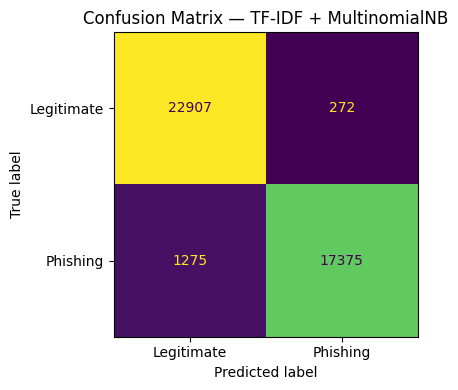

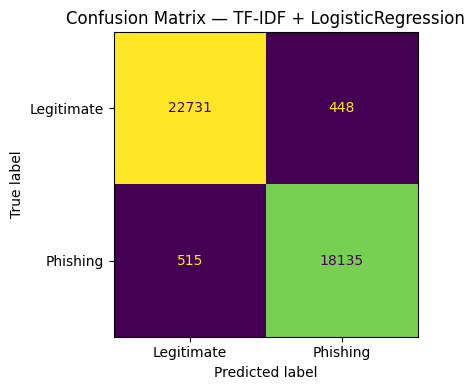

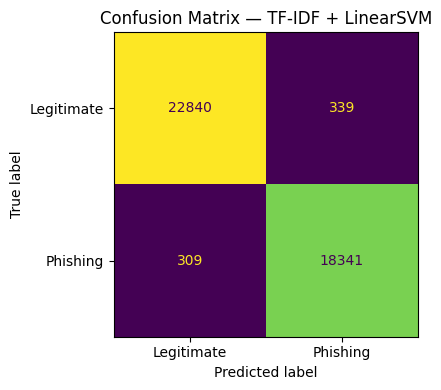

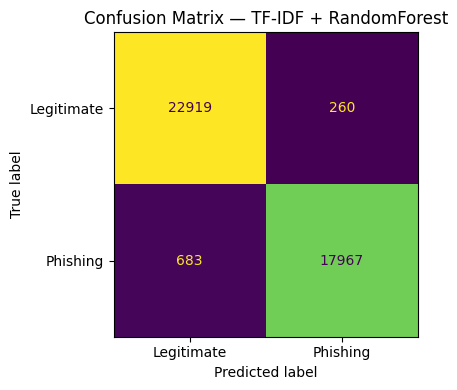

In [10]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

# Create the figures folder if it doesn't already exist
figures_dir = Path("../results/figures/")
figures_dir.mkdir(parents=True, exist_ok=True)

# Use the already-trained models and their predictions from the cells above
trained_models = {
    "TF-IDF + MultinomialNB": nb_pred,
    "TF-IDF + LogisticRegression": lr_pred,
    "TF-IDF + LinearSVM": svm_pred,
    "TF-IDF + RandomForest": rf_pred,
}

for name, y_pred in trained_models.items():
    # Build the confusion matrix using the stored predictions
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Legitimate", "Phishing"])

    fig, ax = plt.subplots(figsize=(5, 4))
    disp.plot(ax=ax, colorbar=False)
    ax.set_title(f"Confusion Matrix — {name}")
    plt.tight_layout()

    # Save with meajor_ prefix to distinguish from kaggle figures
    safe_name = name.lower().replace(" ", "_").replace("+", "").replace("__", "_")
    plt.savefig(figures_dir / f"meajor_cm_{safe_name}.png", dpi=150)
    plt.show()

## 7. Summary Results Table
A clean side-by-side comparison of all four models on the key deployment-relevant metrics: overall accuracy, F1-score on the phishing class, False Positive Rate, and inference time. This table is the primary reference for the final report and directly extends the metrics reported by Altwaijry et al. (2024), who recorded only accuracy and F1.

In [11]:
import pandas as pd

# Build a concise summary table from the per-model result dictionaries
summary_rows = [
    {k: v for k, v in r.items() if k in ["model", "accuracy", "f1", "false_positive_rate", "inference_time_total_sec"]}
    for r in [results_nb, results_lr, results_svm, results_rf]
]
summary_df = pd.DataFrame(summary_rows).rename(columns={
    "model": "Model",
    "accuracy": "Accuracy",
    "f1": "F1 (Phishing)",
    "false_positive_rate": "FPR",
    "inference_time_total_sec": "Inference Time (s)",
})

print(summary_df.to_string(index=False))

                      Model  Accuracy  F1 (Phishing)      FPR  Inference Time (s)
     TF-IDF + MultinomialNB  0.963016       0.957379 0.011735            0.025330
TF-IDF + LogisticRegression  0.976978       0.974136 0.019328            0.008282
         TF-IDF + LinearSVM  0.984508       0.982641 0.014625            0.009107
      TF-IDF + RandomForest  0.977456       0.974429 0.011217            1.581448


## 8. Save classical baseline results

This section combines the results from all four classical models and saves them for later comparison and reporting.

**Note:** In addition to standard accuracy and F1 (reported in Altwaijry et al. 2024), this notebook also records **inference time** and **False Positive Rate (FPR)** for each model. These deployment-relevant metrics are key differentiators of this project: inference time determines real-time viability, and FPR measures how often legitimate emails are wrongly flagged as phishing.

In [12]:
# Define the directory where we want to save our results
results_dir = Path("../results/metrics")
# Create the directory if it doesn't already exist (parents=True creates intermediate folders if needed)
results_dir.mkdir(parents=True, exist_ok=True)

# Combine the results from all four models into a single DataFrame for easy comparison
results_classical = pd.DataFrame([results_nb, results_lr, results_svm, results_rf])

# Save the combined results to a CSV file (similar to an Excel spreadsheet), without saving the row index numbers
results_classical.to_csv(results_dir / "meajor_classical_baselines_results.csv", index=False)

# Print the final results and the save location to confirm success
print(results_classical)
print()
print("Saved to:", results_dir / "meajor_classical_baselines_results.csv")

  dataset                        model  accuracy  precision    recall  \
0  MeAJOR       TF-IDF + MultinomialNB  0.963016   0.984587  0.931635   
1  MeAJOR  TF-IDF + LogisticRegression  0.976978   0.975892  0.972386   
2  MeAJOR           TF-IDF + LinearSVM  0.984508   0.981852  0.983432   
3  MeAJOR        TF-IDF + RandomForest  0.977456   0.985735  0.963378   

         f1  false_positive_rate  inference_time_total_sec  \
0  0.957379             0.011735                  0.025330   
1  0.974136             0.019328                  0.008282   
2  0.982641             0.014625                  0.009107   
3  0.974429             0.011217                  1.581448   

   inference_time_per_email_sec  train_rows  test_rows  vocab_size  
0                  6.055697e-07       62743      41829       50000  
1                  1.980026e-07       62743      41829       50000  
2                  2.177217e-07       62743      41829       50000  
3                  3.780745e-05       62743    

In [13]:
# Define the directory where we want to save our results
results_dir = Path("../results/metrics")
# Create the directory if it doesn't already exist (parents=True creates intermediate folders if needed)
results_dir.mkdir(parents=True, exist_ok=True)

# Save the combined results to a CSV file (similar to an Excel spreadsheet), without saving the row index numbers
results_classical.to_csv(results_dir / "meajor_classical_baselines_results.csv", index=False)

# Print the final results and the save location to confirm success
print(results_classical)
print()
print("Saved to:", results_dir / "meajor_classical_baselines_results.csv")

  dataset                        model  accuracy  precision    recall  \
0  MeAJOR       TF-IDF + MultinomialNB  0.963016   0.984587  0.931635   
1  MeAJOR  TF-IDF + LogisticRegression  0.976978   0.975892  0.972386   
2  MeAJOR           TF-IDF + LinearSVM  0.984508   0.981852  0.983432   
3  MeAJOR        TF-IDF + RandomForest  0.977456   0.985735  0.963378   

         f1  false_positive_rate  inference_time_total_sec  \
0  0.957379             0.011735                  0.025330   
1  0.974136             0.019328                  0.008282   
2  0.982641             0.014625                  0.009107   
3  0.974429             0.011217                  1.581448   

   inference_time_per_email_sec  train_rows  test_rows  vocab_size  
0                  6.055697e-07       62743      41829       50000  
1                  1.980026e-07       62743      41829       50000  
2                  2.177217e-07       62743      41829       50000  
3                  3.780745e-05       62743    